# **Kütüphaneleri İndirme**

In [1]:
import pandas as pd
import os
import polars as pl
from pathlib import Path

import gzip
import json
from IPython.display import Markdown, display #Reference dosyası için

import matplotlib.pyplot as plt
from datetime import datetime

# **Datasetleri Okuma, Parse Etme ve Class'a Alma Yeri**

In [2]:
DATA_DIR = Path(
    r"C:\Users\kerem\Desktop\capsstone\data"
)

customer_complaints_db = pl.scan_ndjson(
    DATA_DIR / "customer_complaints.json.gz"
)

customer_spending_db = pl.scan_ndjson(
    DATA_DIR / "customer_spending.json.gz"
)

customer_db = pl.scan_ndjson(
    DATA_DIR / "customer.json.gz"
)

datasets = {
    "customer_complaints": customer_complaints_db,
    "customer_spending": customer_spending_db,
    "customer": customer_db,
}

# **Datasetleri Anlama Kısımları ve Özelliklerine Bakma Yeri**

In [3]:
def dataset_info(name, lazy_df, sample_size=5):
    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    schema = lazy_df.collect_schema()

    row_count = (
        lazy_df
        .select(pl.len().alias("row_count"))
        .collect(engine="streaming")
        .item()
    )

    column_report = pl.DataFrame({
        "column": schema.names(),
        "dtype": [
            str(dtype)
            for dtype in schema.dtypes()
        ],
    })

    sample = (
        lazy_df
        .head(sample_size)
        .collect()
    )

    print(f"Satır sayısı : {row_count:,}")
    print(f"Sütun sayısı : {len(schema)}")

    print("\nSÜTUN BİLGİLERİ")
    display(column_report)

    print("\nİLK 5 SATIR")
    display(sample)

    return column_report

In [5]:
dataset_reports = {}

for name, lazy_df in datasets.items():
    dataset_reports[name] = dataset_info(
        name,
        lazy_df,
    )

DATASET: customer_complaints
Satır sayısı : 2,163,345
Sütun sayısı : 5

SÜTUN BİLGİLERİ


column,dtype
str,str
"""customer_id""","""Int64"""
"""billing_year_month""","""String"""
"""problem_category""","""String"""
"""problem_subcategory""","""String"""
"""chat_history""","""List(Struct({'history_id': Int…"



İLK 5 SATIR


customer_id,billing_year_month,problem_category,problem_subcategory,chat_history
i64,str,str,str,list[struct[3]]
1,"""202302""","""speed""","""slow_upload""","[{1,""customer"",""Dosya yuklemek sonsuza kadar suruyor, upload hizi cok dusuk.""}, {2,""agent"",""Bir kayit olusturdum, teknik ekibimiz en kisa surede sizinle ilgilenecek.""}, … {6,""agent"",""Sorununuz cozulmustur. Yardimci olabilecegim baska bir konu var mi?""}]"
1,"""202303""","""coverage""","""no_signal""","[{1,""customer"",""Telefonumda hic cekmiyor, hicbir sekilde sebeke bulamiyorum.""}, {2,""agent"",""Bir teknisyen yonlendirildi, belirlenen zaman araliginda adresinize gelecek.""}]"
1,"""202306""","""data""","""slow_data""","[{1,""customer"",""Mobil internet inanilmaz yavas, sayfalar acilmiyor.""}, {2,""agent"",""Modeminizi yeniden baslatip sorunun devam edip etmedigini bana bildirir misiniz?""}, … {8,""agent"",""Hesabinizda gerekli duzeltme yapildi ve bir sonraki faturaniza yansiyacak.""}]"
1,"""202306""","""coverage""","""indoor_coverage""","[{1,""customer"",""Ev veya is yeri icinde sinyal neredeyse hic yok.""}, {2,""agent"",""Yapilandirmayi kendi tarafimizdan sifirliyorum, bu birkac dakika surebilir.""}, … {4,""agent"",""Hesabinizda gerekli duzeltme yapildi ve bir sonraki faturaniza yansiyacak.""}]"
1,"""202306""","""data""","""tethering_issue""","[{1,""customer"",""Telefonumu modem olarak kullanamiyorum, baglanti paylasilmiyor.""}, {2,""agent"",""Baglantiniz uzerinde hizli bir tani calistirdim ve bazi anormallikler goruyorum.""}, … {6,""agent"",""Kendi tarafimizdan bir duzeltme uyguladik. Hizmetinizin calistigini teyit eder misiniz?""}]"


DATASET: customer_spending
Satır sayısı : 4,323,254
Sütun sayısı : 4

SÜTUN BİLGİLERİ


...

customer_id,billing_year_month,bill_amount,data_usage
i64,str,f64,f64
1,"""202301""",21.447253,95.7618
1,"""202302""",28.783292,135.854895
1,"""202303""",29.696641,144.739975
1,"""202304""",18.465342,136.913267
1,"""202305""",20.54286,96.634113


DATASET: customer
Satır sayısı : 200,000
Sütun sayısı : 3

SÜTUN BİLGİLERİ


column,dtype
str,str
"""customer_id""","""Int64"""
"""city""","""String"""
"""birth_year""","""Int64"""



İLK 5 SATIR


customer_id,city,birth_year
i64,str,i64
1,"""istanbul""",1949
2,"""ankara""",1960
3,"""izmir""",2002
4,"""gaziantep""",1992
5,"""istanbul""",1953


# **Okuması Zor Olan Dataseti Farklı Yöntemle Okuduk**

In [52]:
reference_path = Path(
    r"C:\Users\kerem\Desktop\capsstone\data\reference_material.json.gz"
)

with gzip.open(reference_path, "rt", encoding="utf-8") as file:
    raw_text = file.read()

decoder = json.JSONDecoder() #JSON verisini çözmek için bir JSONDecoder nesnesi oluşturdum.
records = []
position = 0

while position < len(raw_text):
    while position < len(raw_text) and raw_text[position].isspace():
        position += 1

    if position >= len(raw_text):
        break

    record, position = decoder.raw_decode(raw_text, position)
    records.append(record)

reference_df = pl.DataFrame(records)

print(f"Satır sayısı: {reference_df.height}")
print(f"Sütun sayısı: {reference_df.width}")
print(f"Sütunlar: {reference_df.columns}")
print(f"Null sayıları:\n{reference_df.null_count()}")

display(reference_df.head())

print("İlk reference dokümanı:")
display(Markdown(reference_df["content"][0]))

Satır sayısı: 1000
Sütun sayısı: 2
Sütunlar: ['document_id', 'content']
Null sayıları:
shape: (1, 2)
┌─────────────┬─────────┐
│ document_id ┆ content │
│ ---         ┆ ---     │
│ u32         ┆ u32     │
╞═════════════╪═════════╡
│ 0           ┆ 0       │
└─────────────┴─────────┘


document_id,content
str,str
"""DOC000001""","""# Yazilim Sorunu **Kategori:*…"
"""DOC000002""","""# Tek Yonlu Ses **Kategori:**…"
"""DOC000003""","""# Kurulum Gecikmesi **Kategor…"
"""DOC000004""","""# Modem Arizasi **Kategori:**…"
"""DOC000005""","""# eSIM Kurulumu **Kategori:**…"


İlk reference dokümanı:


# Yazilim Sorunu

**Kategori:** Donanim

## Sorun
Son yazilim guncellemesinden sonra modem duzgun calismiyor.

## Cozum Adimlari
1. Sebeke ayarlarini sifirlayin.
2. Cihazinizi kapatip yeniden baslatin.
3. Uygulamayi guncel surume yukseltin.
4. Fatura detaylarini hesabim sayfasindan inceleyin.
5. SIM karti cikarip yeniden takin.

## Notlar
Bu dokuman Donanim kategorisindeki 'firmware_issue' sorununun giderilmesi icin hazirlanmistir.

# **Müşteri Analizi Burada Amaç Geri Gelen Geri Gelmeyen ve Hiç Gitmeyen Müşteri Portfoyu**


In [6]:
spending_lf = (
    customer_spending_db
    .with_columns(
        (
            pl.col("billing_year_month")
            .str.slice(0, 4)
            .cast(pl.Int32) * 12
            +
            pl.col("billing_year_month")
            .str.slice(4, 2)
            .cast(pl.Int32)
        ).alias("month_index")
    )
    .sort(["customer_id", "month_index"])
    .with_columns(
        pl.col("month_index")
        .diff()
        .over("customer_id")
        .alias("month_difference")
    )
)

dataset_bounds = (
    spending_lf
    .select(
        pl.col("month_index")
        .min()
        .alias("first_month_index"),

        pl.col("month_index")
        .max()
        .alias("last_month_index"),
    )
    .collect()
    .row(0, named=True)
)

dataset_first_month = dataset_bounds[
    "first_month_index"
]

dataset_last_month = dataset_bounds[
    "last_month_index"
]

# **Değişim Oranları Her Zaman Düşüyor Ancak Hep Düşmüş (Müşteri Sayısı)**

billing_year_month,customer_count,previous_customer_count,customer_ratio,customer_difference,change_percent
str,u32,u32,f64,i64,f64
"""202301""",200000,null,null,null,null
"""202302""",191980,200000,0.9599,-8020,-4.01
"""202303""",184591,191980,0.961512,-7389,-3.848838
"""202304""",177544,184591,0.961824,-7047,-3.817629
"""202305""",170831,177544,0.96219,-6713,-3.781035
…,…,…,…,…,…
"""202508""",82691,83985,0.984592,-1294,-1.540751
"""202509""",81204,82691,0.982017,-1487,-1.798261
"""202510""",79911,81204,0.984077,-1293,-1.592286


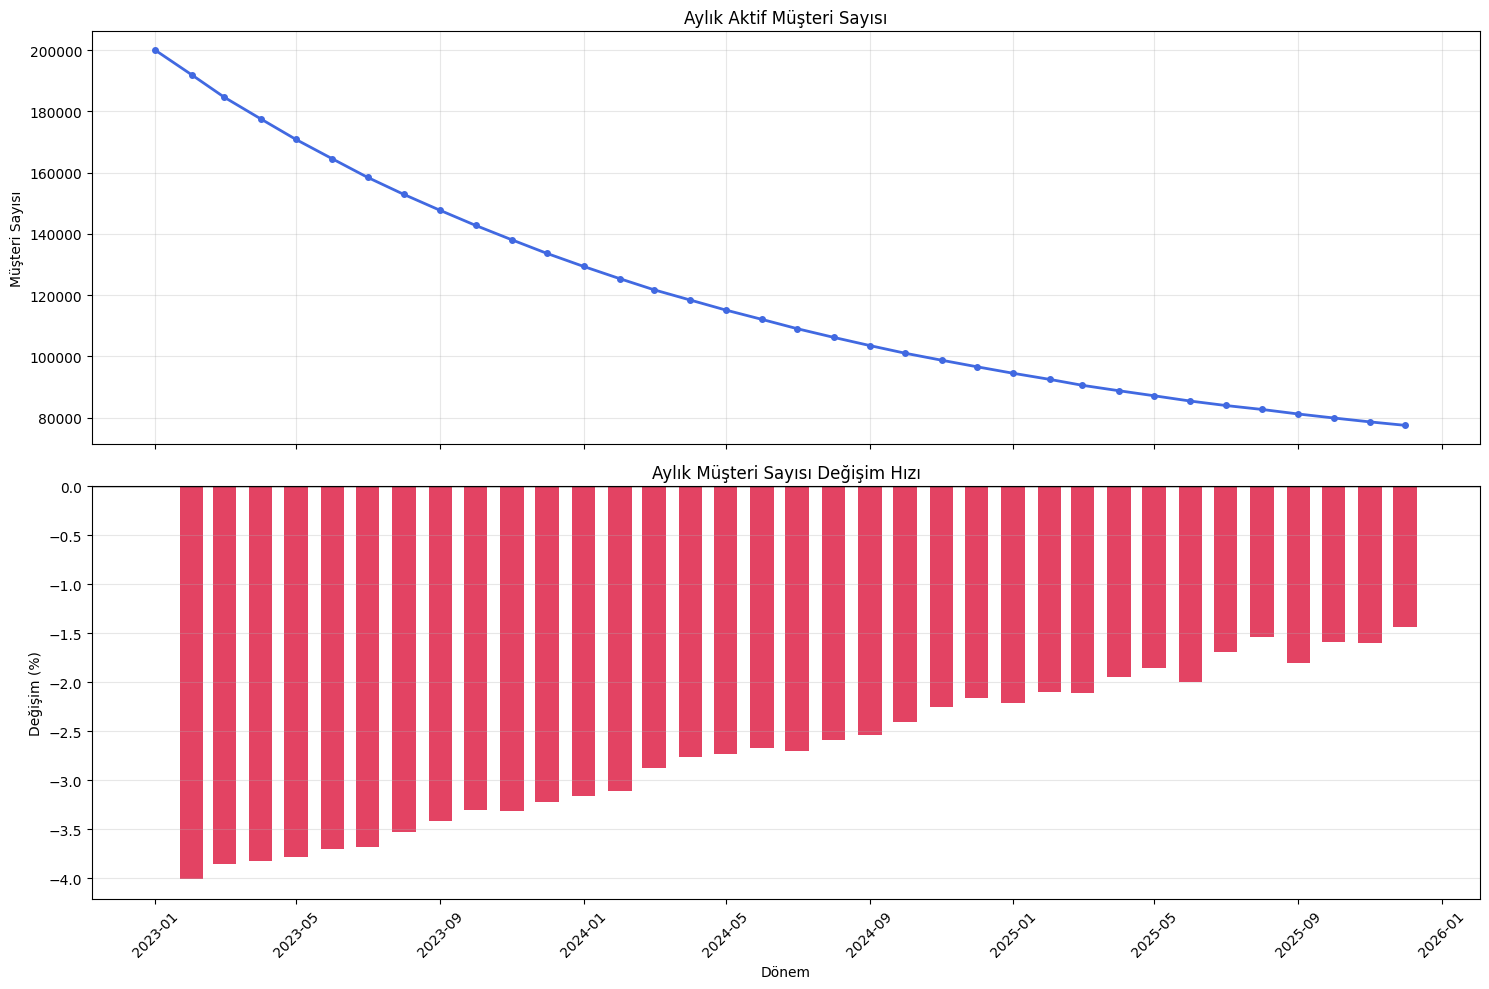

In [7]:

# Her ay aktif olan benzersiz müşteri sayısı
monthly_customer_change = (
    customer_spending_db
    .group_by("billing_year_month")
    .agg(
        pl.col("customer_id")
        .n_unique()
        .alias("customer_count")
    )
    .sort("billing_year_month")
    .with_columns(
        pl.col("customer_count")
        .shift(1)
        .alias("previous_customer_count")
    )
    .with_columns([
        (
            pl.col("customer_count")
            / pl.col("previous_customer_count")
        ).alias("customer_ratio"),

        (
            pl.col("customer_count").cast(pl.Int64)
            - pl.col("previous_customer_count").cast(pl.Int64)
        ).alias("customer_difference"),

        (
            (
                pl.col("customer_count")
                / pl.col("previous_customer_count")
            ) - 1
        ).mul(100).alias("change_percent"),
    ])
    .collect()
)

display(monthly_customer_change)

# Grafik için tarihleri dönüştür
dates = [
    datetime.strptime(month, "%Y%m")
    for month in monthly_customer_change["billing_year_month"]
]

customer_counts = monthly_customer_change["customer_count"].to_list()
change_rates = monthly_customer_change["change_percent"].to_list()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 10),
    sharex=True
)

# 1. Aylık toplam aktif müşteri
axes[0].plot(
    dates,
    customer_counts,
    marker="o",
    markersize=4,
    linewidth=2,
    color="royalblue",
)

axes[0].set_title("Aylık Aktif Müşteri Sayısı")
axes[0].set_ylabel("Müşteri Sayısı")
axes[0].grid(alpha=0.3)

# 2. Önceki aya göre değişim yüzdesi
bar_colors = [
    "seagreen" if value >= 0 else "crimson"
    for value in change_rates[1:]
]

axes[1].bar(
    dates[1:],
    change_rates[1:],
    width=20,
    color=bar_colors,
    alpha=0.8,
)

axes[1].axhline(
    y=0,
    color="black",
    linewidth=1,
)

axes[1].set_title("Aylık Müşteri Sayısı Değişim Hızı")
axes[1].set_ylabel("Değişim (%)")
axes[1].set_xlabel("Dönem")
axes[1].grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
customer_profile_lf = (
    spending_lf
    .group_by("customer_id")
    .agg(
        pl.col("billing_year_month")
        .min()
        .alias("first_month"),

        pl.col("billing_year_month")
        .max()
        .alias("last_month"),

        pl.col("month_index")
        .min()
        .alias("first_month_index"),

        pl.col("month_index")
        .max()
        .alias("last_month_index"),

        pl.col("billing_year_month")
        .n_unique()
        .alias("active_months"),

        (
            pl.col("month_difference") > 1
        )
        .sum()
        .alias("return_count"),

        pl.col("bill_amount")
        .median()
        .alias("median_bill_amount"),

        pl.col("bill_amount")
        .mean()
        .alias("mean_bill_amount"),

        pl.col("data_usage")
        .median()
        .alias("median_data_usage"),

        pl.col("data_usage")
        .mean()
        .alias("mean_data_usage"),
    )
    .with_columns(
        (
            pl.col("last_month_index")
            - pl.col("first_month_index")
            + 1
            - pl.col("active_months")
        ).alias("inactive_months_between"),

        (
            pl.col("first_month_index")
            > dataset_first_month
        ).alias("is_new_customer"),

        (
            pl.col("last_month_index")
            < dataset_last_month
        ).alias("is_gone_now"),
    )
    .with_columns(
        pl.when(
            pl.col("is_gone_now")
            & (pl.col("return_count") == 0)
        )
        .then(pl.lit("gitmis_tekte_ayrilmis"))

        .when(
            pl.col("is_gone_now")
            & (pl.col("return_count") == 1)
        )
        .then(
            pl.lit(
                "gitmis_bir_kez_donup_sonra_ayrilmis"
            )
        )

        .when(
            pl.col("is_gone_now")
            & (pl.col("return_count") >= 2)
        )
        .then(
            pl.lit(
                "gitmis_birden_fazla_donup_sonra_ayrilmis"
            )
        )

        .when(
            ~pl.col("is_gone_now")
            & (pl.col("return_count") >= 1)
        )
        .then(pl.lit("gitmis_geri_gelmis"))

        .otherwise(pl.lit("hic_gitmemis"))
        .alias("customer_segment")
    )
)

In [56]:
complaint_summary_lf = (
    customer_complaints_db
    .select(
        "customer_id",
        pl.col("chat_history")
        .list.len()
        .alias("chat_message_count"),
    )
    .group_by("customer_id")
    .agg(
        pl.len().alias("complaint_count"),

        pl.col("chat_message_count")
        .sum()
        .alias("total_chat_message_count"),
    )
)

customer_profile = (
    customer_profile_lf
    .join(
        customer_db,
        on="customer_id",
        how="left",
    )
    .join(
        complaint_summary_lf,
        on="customer_id",
        how="left",
    )
    .with_columns(
        pl.col("complaint_count").fill_null(0),

        pl.col("total_chat_message_count")
        .fill_null(0),
    )
    .collect(engine="streaming")
)

segment_summary = (
    customer_profile
    .group_by("customer_segment")
    .agg(
        pl.len().alias("customer_count"),

        pl.col("active_months")
        .median()
        .alias("median_active_months"),

        pl.col("return_count")
        .median()
        .alias("median_return_count"),

        pl.col("median_bill_amount")
        .median()
        .alias("segment_median_bill"),

        pl.col("median_data_usage")
        .median()
        .alias("segment_median_usage"),

        pl.col("complaint_count")
        .median()
        .alias("median_complaint_count"),
    )
    .sort("customer_count", descending=True)
)

display(customer_profile.head())
display(segment_summary)

customer_id,first_month,last_month,first_month_index,last_month_index,active_months,return_count,median_bill_amount,mean_bill_amount,median_data_usage,mean_data_usage,inactive_months_between,is_new_customer,is_gone_now,customer_segment,city,birth_year,complaint_count,total_chat_message_count
i64,str,str,i32,i32,u32,u32,f64,f64,f64,f64,i64,bool,bool,str,str,i64,u32,u32
4237,"""202301""","""202509""",24277,24309,33,0,28.544481,29.192585,121.970358,132.553478,0,false,true,"""gitmis_tekte_ayrilmis""","""adana""",1974,19,80
4348,"""202301""","""202507""",24277,24307,25,1,20.682881,21.046108,106.289099,116.166464,6,false,true,"""gitmis_bir_kez_donup_sonra_ayr…","""bursa""",1997,12,44
4591,"""202301""","""202310""",24277,24286,10,0,61.148265,62.313916,278.847137,267.541261,0,false,true,"""gitmis_tekte_ayrilmis""","""istanbul""",1949,7,42
4645,"""202301""","""202512""",24277,24312,36,0,18.443045,18.729106,117.709314,118.408691,0,false,false,"""hic_gitmemis""","""istanbul""",1986,22,100
4674,"""202301""","""202305""",24277,24281,5,0,29.121421,28.116768,102.823619,109.784038,0,false,true,"""gitmis_tekte_ayrilmis""","""gaziantep""",1964,1,4


customer_segment,customer_count,median_active_months,median_return_count,segment_median_bill,segment_median_usage,median_complaint_count
str,u32,f64,f64,f64,f64,f64
"""gitmis_tekte_ayrilmis""",107807,14.0,0.0,29.291903,131.964891,7.0
"""hic_gitmemis""",49619,36.0,0.0,35.247959,136.827534,16.0
"""gitmis_geri_gelmis""",27883,23.0,1.0,26.883641,124.22312,11.0
"""gitmis_bir_kez_donup_sonra_ayr…",14066,16.0,1.0,25.842937,123.564359,9.0
"""gitmis_birden_fazla_donup_sonr…",625,17.0,2.0,25.5528,120.91588,11.0


# **Datasetlere Ayırma Yeri Parquet Formatta Çünkü Büyük Verilerde Lazım Oluyor**

In [57]:
output_dir = Path(
    r"C:\Users\kerem\Desktop\capsstone\data\processing_data"
)
output_dir.mkdir(parents=True, exist_ok=True)

segments = [
    "gitmis_tekte_ayrilmis",
    "hic_gitmemis",
    "gitmis_geri_gelmis",
    "gitmis_bir_kez_donup_sonra_ayrilmis",
    "gitmis_birden_fazla_donup_sonra_ayrilmis",
]

saved_datasets = {}

for segment in segments:
    segment_df = customer_profile.filter(
        pl.col("customer_segment") == segment
    )

    output_path = output_dir / f"{segment}.parquet"

    segment_df.write_parquet(
        output_path,
        compression="zstd",
    )

    saved_datasets[segment] = segment_df

    print(
        f"{segment}: "
        f"{segment_df.height:,} müşteri → {output_path.name}"
    )

# Kontrol
saved_total = sum(df.height for df in saved_datasets.values())

print("-" * 60)
print(f"Kaydedilen toplam müşteri: {saved_total:,}")
print(f"Customer profile toplamı : {customer_profile.height:,}")

if saved_total == customer_profile.height:
    print("Kontrol başarılı: Bütün müşteriler kaydedildi.")
else:
    print("Uyarı: Segment dışında kalan müşteri bulunuyor.")

gitmis_tekte_ayrilmis: 107,807 müşteri → gitmis_tekte_ayrilmis.parquet
hic_gitmemis: 49,619 müşteri → hic_gitmemis.parquet
gitmis_geri_gelmis: 27,883 müşteri → gitmis_geri_gelmis.parquet
gitmis_bir_kez_donup_sonra_ayrilmis: 14,066 müşteri → gitmis_bir_kez_donup_sonra_ayrilmis.parquet
gitmis_birden_fazla_donup_sonra_ayrilmis: 625 müşteri → gitmis_birden_fazla_donup_sonra_ayrilmis.parquet
------------------------------------------------------------
Kaydedilen toplam müşteri: 200,000
Customer profile toplamı : 200,000
Kontrol başarılı: Bütün müşteriler kaydedildi.


In [58]:
gitmis_tekte_ayrilmis_df = pl.read_parquet(
    output_dir / "gitmis_tekte_ayrilmis.parquet"
)

hic_gitmemis_df = pl.read_parquet(
    output_dir / "hic_gitmemis.parquet"
)

gitmis_geri_gelmis_df = pl.read_parquet(
    output_dir / "gitmis_geri_gelmis.parquet"
)

gitmis_bir_kez_donup_sonra_ayrilmis_df = pl.read_parquet(
    output_dir / "gitmis_bir_kez_donup_sonra_ayrilmis.parquet"
)

gitmis_birden_fazla_donup_sonra_ayrilmis_df = pl.read_parquet(
    output_dir / "gitmis_birden_fazla_donup_sonra_ayrilmis.parquet"
)

# **Bundan Sonra Focus Olacağımız İnsan Sayısı Azaldı**

**FOCUS OLACAĞIMIZ KISIMLAR ŞEHİR YAŞ GB KULLANIMI FİYAT FAZLALIĞI YANİ GİDEN NEDEN GİTTİ**

**print(
    "Şikâyet geçiş analizi geçici olarak kapatıldı. "
    "Eski many-to-many join kernelin çökmesine neden oluyordu."
)**

In [59]:
departure_issue_datasets = {}

# **Verisetlerindeki Şikayet Oranlarına Baktık**

# **Para-İnsan İlişkisi**

**Lazım Olan Paradır Şirket Para Kazanıyım derken müşteriler gitmiş**

In [60]:
import polars as pl
import matplotlib.pyplot as plt

from datetime import datetime
from matplotlib.ticker import FuncFormatter

pl.Config.set_fmt_float("full")
pl.Config.set_tbl_cols(20)

money_spending_lf = spending_lf
    .sort(["customer_id", "month_index"])
    .with_columns(
        pl.col("month_index")
        .diff()
        .over("customer_id")
        .alias("month_difference")
    )
)

dataset_period = (
    money_spending_lf
    .select(
        pl.col("month_index")
        .min()
        .alias("first_month_index"),

        pl.col("month_index")
        .max()
        .alias("last_month_index"),

        pl.col("billing_year_month")
        .min()
        .alias("first_month"),

        pl.col("billing_year_month")
        .max()
        .alias("last_month"),
    )
    .collect()
    .row(0, named=True)
)

last_month_index = dataset_period[
    "last_month_index"
]

last_month = dataset_period["last_month"]

print(
    f"Analiz dönemi: "
    f"{dataset_period['first_month']} - {last_month}"
)

Analiz dönemi: 202301 - 202512


In [61]:
customer_finance = (
    money_spending_lf
    .group_by("customer_id")
    .agg(
        pl.col("month_index")
        .min()
        .alias("first_active_month_index"),

        pl.col("month_index")
        .max()
        .alias("last_active_month_index"),

        pl.col("billing_year_month")
        .min()
        .alias("first_active_month"),

        pl.col("billing_year_month")
        .max()
        .alias("last_active_month"),

        pl.col("billing_year_month")
        .n_unique()
        .alias("active_month_count"),

        (
            pl.col("month_difference") > 1
        )
        .sum()
        .alias("return_count"),

        pl.col("bill_amount")
        .sum()
        .alias("historical_total_paid"),

        pl.col("bill_amount")
        .mean()
        .alias("lifetime_average_bill"),

        pl.col("bill_amount")
        .median()
        .alias("lifetime_median_bill"),

        pl.col("bill_amount")
        .sort_by("month_index")
        .last()
        .alias("last_bill"),

        pl.col("bill_amount")
        .sort_by("month_index")
        .tail(3)
        .mean()
        .alias("last_3_month_average_bill"),
    )
    .collect(engine="streaming")
)

print(
    f"Finans profili oluşturulan müşteri: "
    f"{customer_finance.height:,}"
)

Finans profili oluşturulan müşteri: 200,000


In [62]:
lost_customers = (
    customer_finance
    .filter(
        pl.col("last_active_month_index")
        < last_month_index
    )
    .with_columns(
        (
            last_month_index
            - pl.col("last_active_month_index")
        ).alias("lost_month_count")
    )
    .with_columns(
        (
            pl.col("last_3_month_average_bill")
            * pl.col("lost_month_count")
        ).alias("total_estimated_revenue_loss"),

        pl.when(pl.col("return_count") == 0)
        .then(pl.lit("Doğrudan ayrılan"))

        .when(pl.col("return_count") == 1)
        .then(pl.lit("Bir kez dönüp ayrılan"))

        .otherwise(
            pl.lit("Birden fazla dönüp ayrılan")
        )
        .alias("customer_segment_tr"),
    )
)

print(
    f"Kaybedilen müşteri: "
    f"{lost_customers.height:,}"
)

Kaybedilen müşteri: 122,498


In [63]:
loss_calculation_check = (
    lost_customers
    .select(
        "customer_id",
        "last_active_month",
        "lost_month_count",
        "last_3_month_average_bill",
        "total_estimated_revenue_loss",
    )
    .sort(
        "lost_month_count",
        descending=True,
    )
    .head(20)
)

display(loss_calculation_check)

customer_id,last_active_month,lost_month_count,last_3_month_average_bill,total_estimated_revenue_loss
i64,str,i32,f64,f64
49,"""202301""",35,27.141563075334947,949.9547076367231
127,"""202301""",35,33.26510584439994,1164.2787045539978
214,"""202301""",35,75.12627620797547,2629.4196672791413
239,"""202301""",35,26.074609232091788,912.6113231232126
245,"""202301""",35,13.924489292924195,487.3571252523468
…,…,…,…,…
797,"""202301""",35,23.72378083195417,830.3323291183959
804,"""202301""",35,26.986662582440633,944.5331903854221
834,"""202301""",35,24.45630950420863,855.970832647302


In [64]:
total_customer_count = customer_finance.height
lost_customer_count = lost_customers.height

lost_customer_rate = (
    lost_customer_count
    / total_customer_count
    * 100
)

historical_total_paid = (
    lost_customers[
        "historical_total_paid"
    ].sum()
)

total_estimated_revenue_loss = (
    lost_customers[
        "total_estimated_revenue_loss"
    ].sum()
)

total_lost_customer_months = (
    lost_customers[
        "lost_month_count"
    ].sum()
)

average_lost_month_count = (
    lost_customers[
        "lost_month_count"
    ].mean()
)

average_bill_before_departure = (
    lost_customers[
        "last_3_month_average_bill"
    ].mean()
)

loss_kpi_summary = pl.DataFrame({
    "Gösterge": [
        "Toplam müşteri sayısı",
        "Kaybedilen müşteri sayısı",
        "Kaybedilen müşteri oranı (%)",
        "Toplam kayıp müşteri-ayı",
        "Ortalama kayıp ay sayısı",
        "Ayrılmadan önce ortalama fatura",
        "Kaybedilenlerin geçmiş toplam ödemesi",
        "Tahmini toplam gelir kaybı",
    ],
    "Değer": [
        float(total_customer_count),
        float(lost_customer_count),
        float(lost_customer_rate),
        float(total_lost_customer_months),
        float(average_lost_month_count),
        float(average_bill_before_departure),
        float(historical_total_paid),
        float(total_estimated_revenue_loss),
    ],
}).with_columns(
    pl.col("Değer").round(2)
)

display(loss_kpi_summary)

Gösterge,Değer
str,f64
"""Toplam müşteri sayısı""",200000
"""Kaybedilen müşteri sayısı""",122498
"""Kaybedilen müşteri oranı (%)""",61.25
"""Toplam kayıp müşteri-ayı""",2348142
"""Ortalama kayıp ay sayısı""",19.17
"""Ayrılmadan önce ortalama fatur…",47.79
"""Kaybedilenlerin geçmiş toplam …",90390247.65
"""Tahmini toplam gelir kaybı""",111490065.18


In [65]:
segment_revenue_summary = (
    lost_customers
    .group_by("customer_segment_tr")
    .agg(
        pl.len()
        .alias("lost_customer_count"),

        pl.col("lost_month_count")
        .sum()
        .alias("total_lost_customer_months"),

        pl.col("lost_month_count")
        .mean()
        .alias("average_lost_month_count"),

        pl.col("last_3_month_average_bill")
        .mean()
        .alias("average_bill_before_departure"),

        pl.col("last_3_month_average_bill")
        .median()
        .alias("median_bill_before_departure"),

        pl.col("historical_total_paid")
        .sum()
        .alias("historical_total_paid"),

        pl.col("total_estimated_revenue_loss")
        .sum()
        .alias("total_estimated_revenue_loss"),
    )
    .with_columns(
        (
            pl.col("lost_customer_count")
            / pl.col("lost_customer_count").sum()
            * 100
        )
        .round(2)
        .alias("lost_customer_share_percent"),

        (
            pl.col("total_estimated_revenue_loss")
            / pl.col(
                "total_estimated_revenue_loss"
            ).sum()
            * 100
        )
        .round(2)
        .alias("revenue_loss_share_percent"),
    )
    .with_columns(
        pl.col(
            "average_lost_month_count",
            "average_bill_before_departure",
            "median_bill_before_departure",
            "historical_total_paid",
            "total_estimated_revenue_loss",
        ).round(2)
    )
    .sort(
        "total_estimated_revenue_loss",
        descending=True,
    )
)

display(segment_revenue_summary)

customer_segment_tr,lost_customer_count,total_lost_customer_months,average_lost_month_count,average_bill_before_departure,median_bill_before_departure,historical_total_paid,total_estimated_revenue_loss,lost_customer_share_percent,revenue_loss_share_percent
str,u32,i32,f64,f64,f64,f64,f64,f64,f64
"""Doğrudan ayrılan""",107807,2207231,20.47,49.65,30.58,82377197.2,106780210,88.01,95.78
"""Bir kez dönüp ayrılan""",14066,137054,9.74,34.34,27.42,7699673.27,4596561.27,11.48,4.12
"""Birden fazla dönüp ayrılan""",625,3857,6.17,29.89,26.97,313377.17,113293.9,0.51,0.1


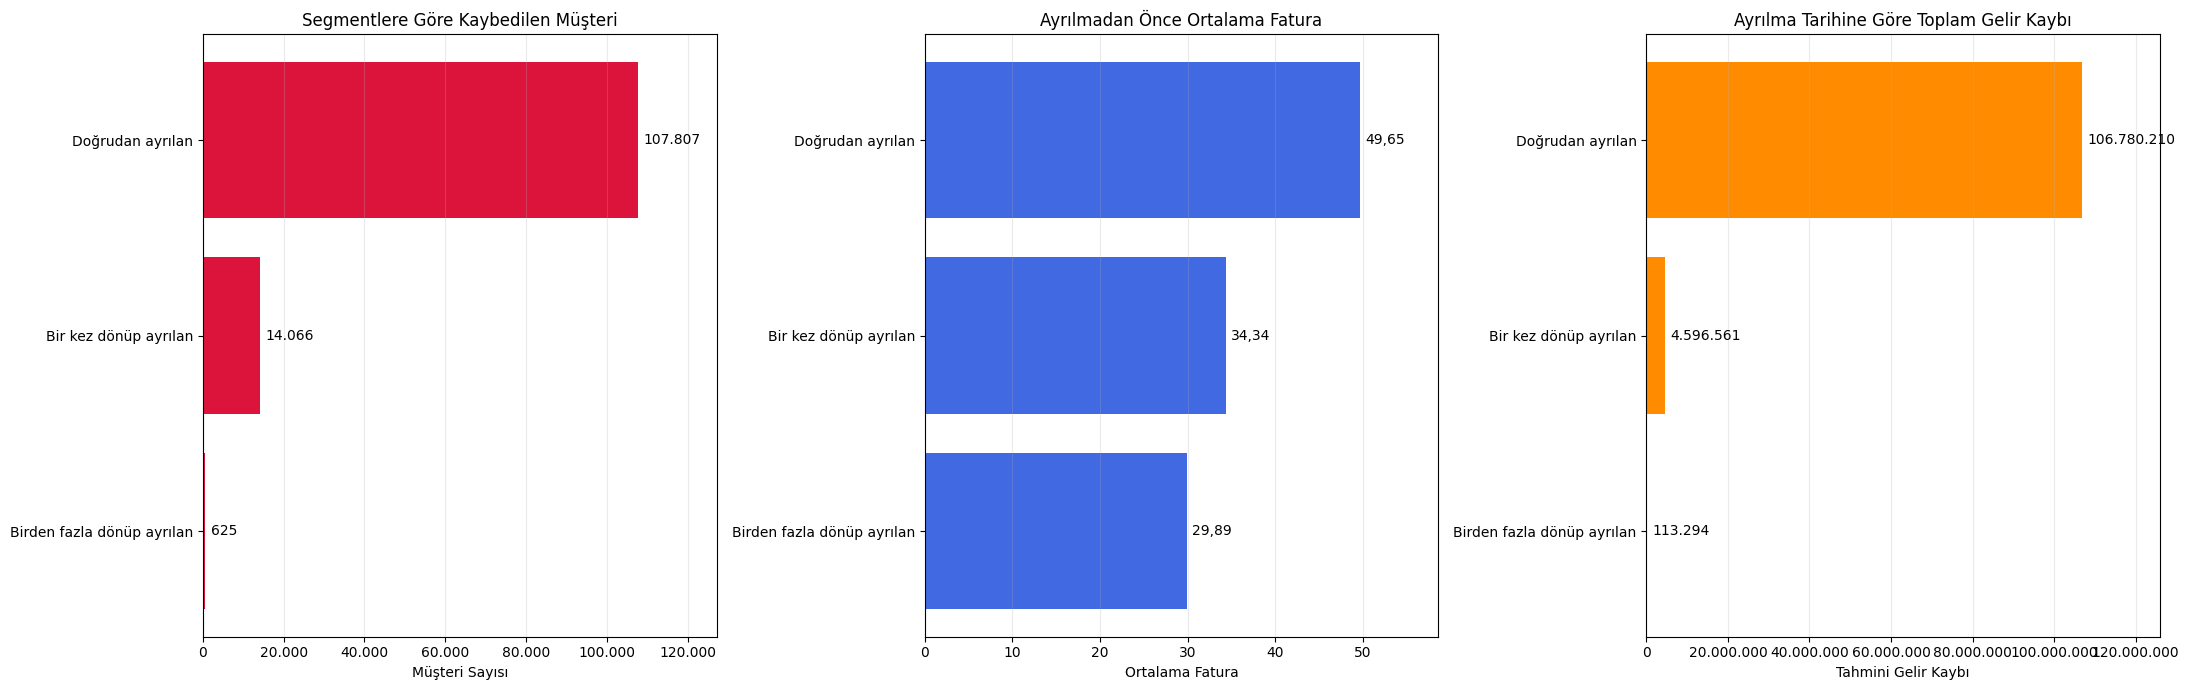

In [70]:
plot_data = segment_revenue_summary.sort(
    "total_estimated_revenue_loss"
)

segments = plot_data[
    "customer_segment_tr"
].to_list()

customer_values = plot_data[
    "lost_customer_count"
].to_list()

bill_values = plot_data[
    "average_bill_before_departure"
].to_list()

loss_values = plot_data[
    "total_estimated_revenue_loss"
].to_list()

number_formatter = FuncFormatter(
    lambda value, _: f"{value:,.0f}".replace(",", ".")
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 7),
)

bars_customer = axes[0].barh(
    segments,
    customer_values,
    color="crimson",
)

axes[0].bar_label(
    bars_customer,
    labels=[
        f"{value:,}".replace(",", ".")
        for value in customer_values
    ],
    padding=4,
)

axes[0].set_title(
    "Segmentlere Göre Kaybedilen Müşteri"
)
axes[0].set_xlabel("Müşteri Sayısı")

bars_bill = axes[1].barh(
    segments,
    bill_values,
    color="royalblue",
)

axes[1].bar_label(
    bars_bill,
    labels=[
        f"{value:,.2f}".replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
        for value in bill_values
    ],
    padding=4,
)

axes[1].set_title(
    "Ayrılmadan Önce Ortalama Fatura"
)
axes[1].set_xlabel("Ortalama Fatura")

bars_loss = axes[2].barh(
    segments,
    loss_values,
    color="darkorange",
)

axes[2].bar_label(
    bars_loss,
    labels=[
        f"{value:,.0f}".replace(",", ".")
        for value in loss_values
    ],
    padding=4,
)

axes[2].set_title(
    "Ayrılma Tarihine Göre Toplam Gelir Kaybı"
)
axes[2].set_xlabel("Tahmini Gelir Kaybı")

for axis in axes:
    axis.xaxis.set_major_formatter(number_formatter)
    axis.grid(axis="x", alpha=0.25)
    axis.margins(x=0.18)

plt.tight_layout()
plt.show()

In [71]:
monthly_departure_summary = (
    lost_customers
    .group_by("last_active_month")
    .agg(
        pl.len()
        .alias("lost_customer_count"),

        pl.col("lost_month_count")
        .mean()
        .alias("average_lost_month_count"),

        pl.col("last_3_month_average_bill")
        .mean()
        .alias("average_bill_before_departure"),

        pl.col("total_estimated_revenue_loss")
        .sum()
        .alias("total_estimated_revenue_loss"),
    )
    .sort("last_active_month")
    .with_columns(
        pl.col(
            "average_lost_month_count",
            "average_bill_before_departure",
            "total_estimated_revenue_loss",
        ).round(2)
    )
)

display(monthly_departure_summary)

last_active_month,lost_customer_count,average_lost_month_count,average_bill_before_departure,total_estimated_revenue_loss
str,u32,f64,f64,f64
"""202301""",4583,35,46.82,7509659.94
"""202302""",4373,34,46,6839267.22
"""202303""",4329,33,48.02,6860587.5
"""202304""",4225,32,46.64,6305292.21
"""202305""",4144,31,48.21,6192741.1
…,…,…,…,…
"""202507""",2977,5,49.45,735994.92
"""202508""",3159,4,47.42,599163.12
"""202509""",3079,3,46.98,433981.33


**Müşterinin Son Aktif Olduğu Aya Göre Kayıp Sayısı**

**Son Aktif Ay Kohortlarının 2025 Aralık'a Kadar Tahmini Gelir Kaybı**

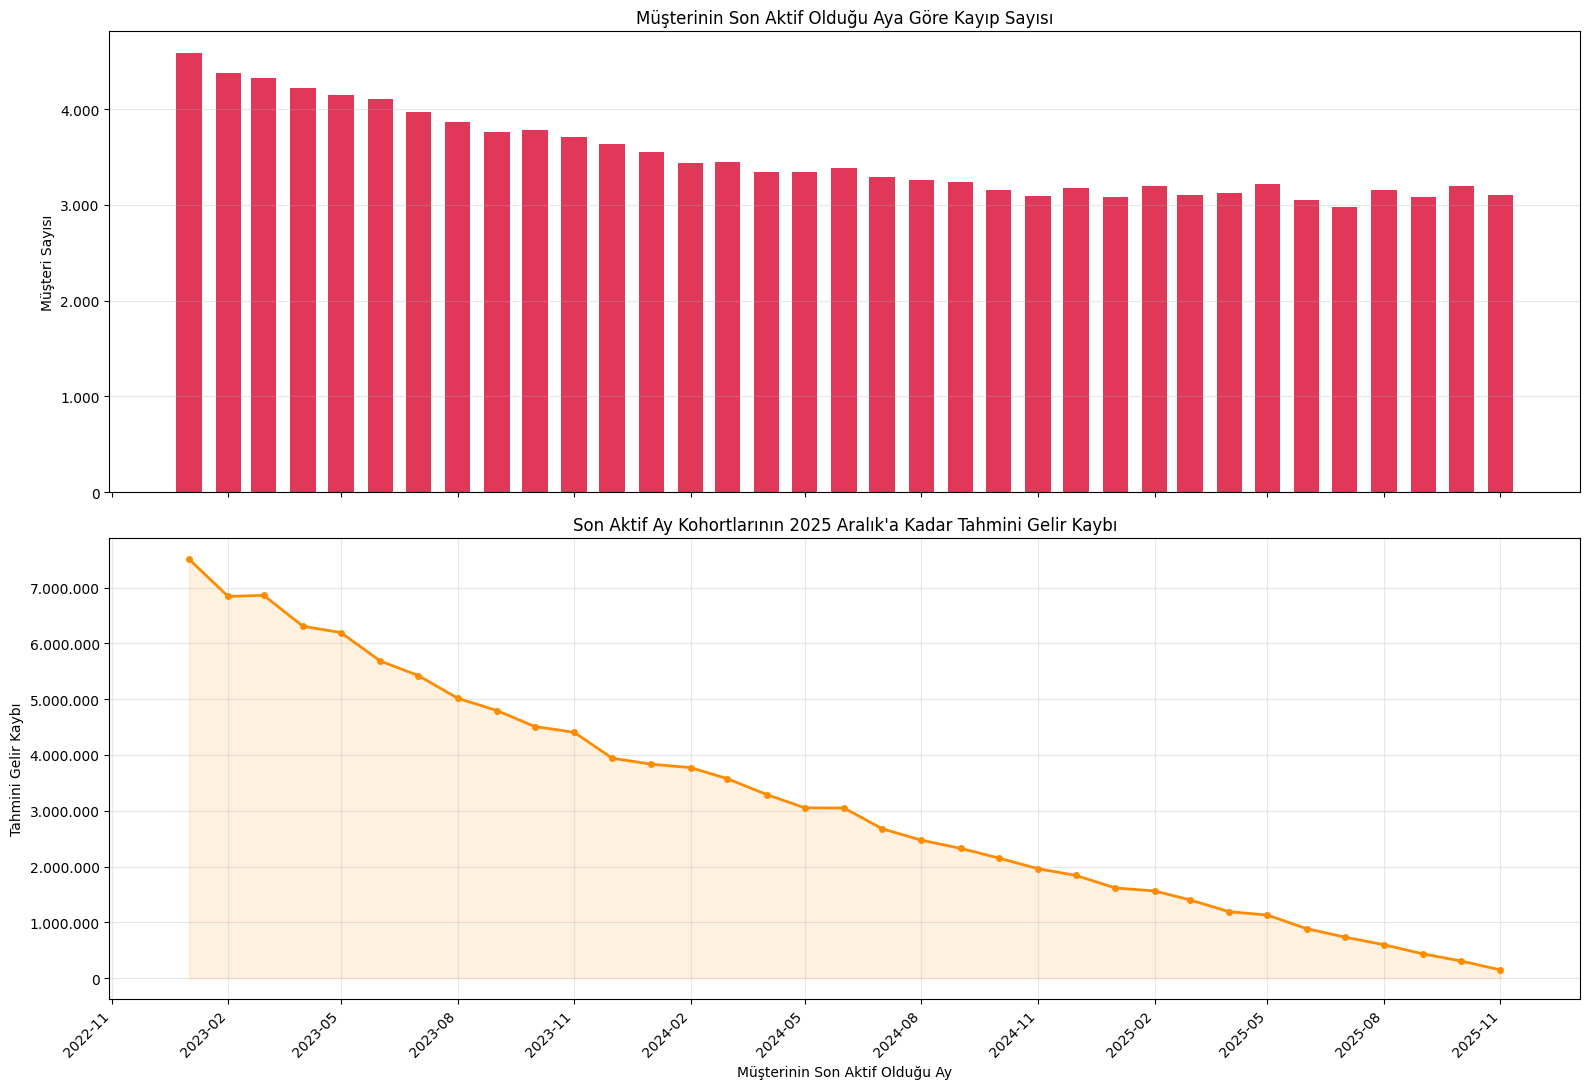

In [73]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime
from matplotlib.ticker import FuncFormatter

# Büyük sayıları Türkçe binlik ayırıcıyla gösterir.
number_formatter = FuncFormatter(
    lambda value, _: f"{value:,.0f}".replace(",", ".")
)

departure_dates = [
    datetime.strptime(value, "%Y%m")
    for value in monthly_departure_summary[
        "last_active_month"
    ].to_list()
]

lost_customer_counts = (
    monthly_departure_summary[
        "lost_customer_count"
    ].to_list()
)

estimated_revenue_losses = (
    monthly_departure_summary[
        "total_estimated_revenue_loss"
    ].to_list()
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 11),
    sharex=True,
)

# Kaybedilen müşteri sayısı
axes[0].bar(
    departure_dates,
    lost_customer_counts,
    width=20,
    color="crimson",
    alpha=0.85,
)

axes[0].set_title(
    "Müşterinin Son Aktif Olduğu Aya Göre Kayıp Sayısı"
)

axes[0].set_ylabel("Müşteri Sayısı")
axes[0].yaxis.set_major_formatter(number_formatter)
axes[0].grid(axis="y", alpha=0.3)

# Tahmini toplam gelir kaybı
axes[1].plot(
    departure_dates,
    estimated_revenue_losses,
    marker="o",
    markersize=4,
    linewidth=2,
    color="darkorange",
)

axes[1].fill_between(
    departure_dates,
    estimated_revenue_losses,
    color="darkorange",
    alpha=0.12,
)

axes[1].set_title(
    "Son Aktif Ay Kohortlarının 2025 Aralık'a Kadar "
    "Tahmini Gelir Kaybı"
)

axes[1].set_ylabel("Tahmini Gelir Kaybı")
axes[1].set_xlabel("Müşterinin Son Aktif Olduğu Ay")
axes[1].yaxis.set_major_formatter(number_formatter)
axes[1].grid(alpha=0.3)

# Tarihleri üçer aylık aralıklarla gösterir.
axes[1].xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.setp(
    axes[1].get_xticklabels(),
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

**Doğrudan Ayrılanlar Ocak 2023**

In [74]:
direct_departures_202301 = (
    lost_customers
    .filter(
        (pl.col("last_active_month") == "202301")
        & (
            pl.col("customer_segment_tr")
            == "Doğrudan ayrılan"
        )
    )
)

print(
    "Doğrudan ayrılan:",
    direct_departures_202301.height,
)

Doğrudan ayrılan: 4583
